# Exploración CASEN 2024

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["font.size"] = 10

def fmt_miles(x, pos):
    """Formatea números grandes como '1.2M', '450K', etc."""
    if abs(x) >= 1_000_000:
        return f"{x/1_000_000:.1f}M"
    if abs(x) >= 1_000:
        return f"{x/1_000:.0f}K"
    return f"{x:.0f}"

FORMATEADOR_MILES = mticker.FuncFormatter(fmt_miles)

### Carga de tablas desde CSV

In [3]:
DIR_TABLAS = "./../tablas"

df_region       = pd.read_csv(f"{DIR_TABLAS}/region.csv")
df_provincia    = pd.read_csv(f"{DIR_TABLAS}/provincia.csv")
df_comuna       = pd.read_csv(f"{DIR_TABLAS}/comuna.csv")
df_nivel_educ   = pd.read_csv(f"{DIR_TABLAS}/nivel_educacional.csv")
df_campo        = pd.read_csv(f"{DIR_TABLAS}/campo_estudio.csv")
df_subcampo     = pd.read_csv(f"{DIR_TABLAS}/subcampo_estudio.csv")
df_cat_ocup     = pd.read_csv(f"{DIR_TABLAS}/categoria_ocupacional.csv")
df_rama         = pd.read_csv(f"{DIR_TABLAS}/rama_economica.csv")
df_subrama      = pd.read_csv(f"{DIR_TABLAS}/subrama_economica.csv")
df_hogar        = pd.read_csv(f"{DIR_TABLAS}/hogar.csv")
df_persona      = pd.read_csv(f"{DIR_TABLAS}/persona.csv")

print(f"Tablas cargadas:")
for nombre, df in [
    ("region", df_region), ("provincia", df_provincia), ("comuna", df_comuna),
    ("nivel_educacional", df_nivel_educ), ("campo_estudio", df_campo),
    ("subcampo_estudio", df_subcampo), ("categoria_ocupacional", df_cat_ocup),
    ("rama_economica", df_rama), ("subrama_economica", df_subrama),
    ("hogar", df_hogar), ("persona", df_persona),
]:
    print(f"  {nombre:25s} {len(df):>7,} filas")

Tablas cargadas:
  region                         16 filas
  provincia                      56 filas
  comuna                        346 filas
  nivel_educacional              15 filas
  campo_estudio                  11 filas
  subcampo_estudio               27 filas
  categoria_ocupacional           9 filas
  rama_economica                 21 filas
  subrama_economica             121 filas
  hogar                      78,654 filas
  persona                   218,367 filas


In [4]:
# Necesitamos region, que está en df_hogar... pero ojo: region no está en df_hogar,
# está derivado del CUT. Lo recuperamos desde Comuna -> Provincia -> Region.
df_hogar_geo = (
    df_hogar
    .merge(df_comuna[["cod_comuna", "cod_provincia"]], on="cod_comuna", how="left")
    .merge(df_provincia[["cod_provincia", "cod_region"]], on="cod_provincia", how="left")
)

df = df_persona.merge(
    df_hogar_geo[["folio", "area", "expr", "expp", "expc", "cod_comuna", "cod_provincia", "cod_region"]],
    on="folio",
    how="left",
)

print(f"Vista plana: {df.shape[0]:,} filas × {df.shape[1]} columnas")
df.head()

Vista plana: 218,367 filas × 17 columnas


,folio,id_persona,sexo,edad,activ,codigo_nivel,codigo_subcampo,codigo_cat_ocup,codigo_subrama,yoprcor,area,expr,expp,expc,cod_comuna,cod_provincia,cod_region
0,100020301,1,1,62,3.0,9.0,NaN,NaN,NaN,NaN,1,264,285,371,13127,131,13
1,100020301,2,2,92,3.0,7.0,NaN,NaN,NaN,NaN,1,264,285,371,13127,131,13
2,100020401,1,1,61,1.0,7.0,NaN,5.0,4805.0,1200000.0,1,295,286,371,13127,131,13
3,100020401,2,2,61,1.0,7.0,NaN,5.0,6801.0,500000.0,1,295,286,371,13127,131,13
4,100020401,3,1,32,1.0,12.0,5.0,5.0,4808.0,700000.0,1,295,286,371,13127,131,13


### Función auxiliar: percentil ponderado

In [5]:
def percentil_ponderado(valores, pesos, p):
    """Percentil p (0-100) ponderado por 'pesos'."""
    valores = np.asarray(valores)
    pesos = np.asarray(pesos)
    orden = np.argsort(valores)
    v = valores[orden]
    w = pesos[orden]
    cum = np.cumsum(w) / w.sum()
    return np.interp(p / 100, cum, v)

# Test rápido
_test = percentil_ponderado([1, 2, 3, 4], [1, 1, 1, 1], 50)
print(f"Mediana de [1,2,3,4] con pesos iguales: {_test}")  # ~2.5

Mediana de [1,2,3,4] con pesos iguales: 2.0


## Demografía base

### Población total y distribución por sexo

In [6]:
poblacion_total = df["expr"].sum()
poblacion_sexo = df.groupby("sexo")["expr"].sum()

print(f"Población estimada total: {poblacion_total:,.0f}")
print(f"  Hombres (sexo=1): {poblacion_sexo[1]:>15,.0f}  ({poblacion_sexo[1]/poblacion_total*100:.1f}%)")
print(f"  Mujeres (sexo=2): {poblacion_sexo[2]:>15,.0f}  ({poblacion_sexo[2]/poblacion_total*100:.1f}%)")

Población estimada total: 20,131,682
  Hombres (sexo=1):       9,931,759  (49.3%)
  Mujeres (sexo=2):      10,199,923  (50.7%)


### Pirámide poblacional por edad y sexo

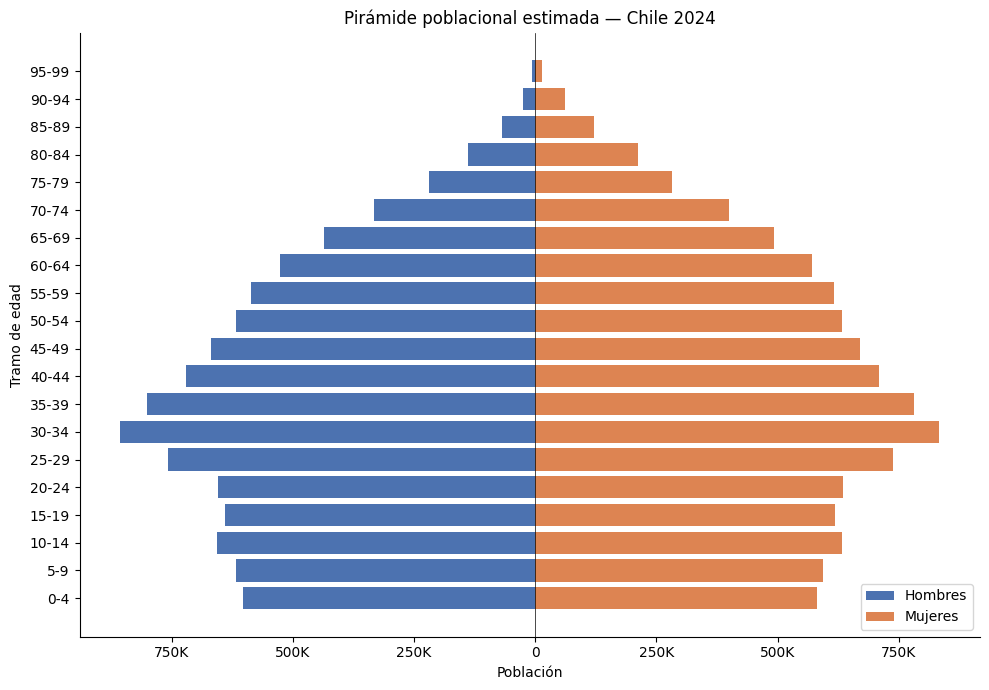

In [7]:
bins_edad = list(range(0, 101, 5))
labels_edad = [f"{b}-{b+4}" for b in bins_edad[:-1]]
df["tramo_edad"] = pd.cut(df["edad"], bins=bins_edad, labels=labels_edad, right=False)

piramide = (
    df.groupby(["tramo_edad", "sexo"], observed=True)["expr"].sum()
    .unstack("sexo")
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(piramide.index, -piramide[1], color="#4C72B0", label="Hombres")
ax.barh(piramide.index,  piramide[2], color="#DD8452", label="Mujeres")
ax.set_xlabel("Población")
ax.set_ylabel("Tramo de edad")
ax.set_title("Pirámide poblacional estimada — Chile 2024")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: fmt_miles(abs(x), p)))
ax.axvline(0, color="black", linewidth=0.5)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

### Distribución urbano vs rural

In [8]:
poblacion_area = df.groupby("area")["expr"].sum()
etiquetas_area = {1: "Urbano", 2: "Rural"}
poblacion_area.index = poblacion_area.index.map(etiquetas_area)

print("Población estimada por zona:")
for zona, pob in poblacion_area.items():
    print(f"  {zona}: {pob:>15,.0f}  ({pob/poblacion_total*100:.1f}%)")

Población estimada por zona:
  Urbano:      17,869,298  (88.8%)
  Rural:       2,262,384  (11.2%)


## Educación

### Nivel educacional más alto alcanzado (adultos 25+)

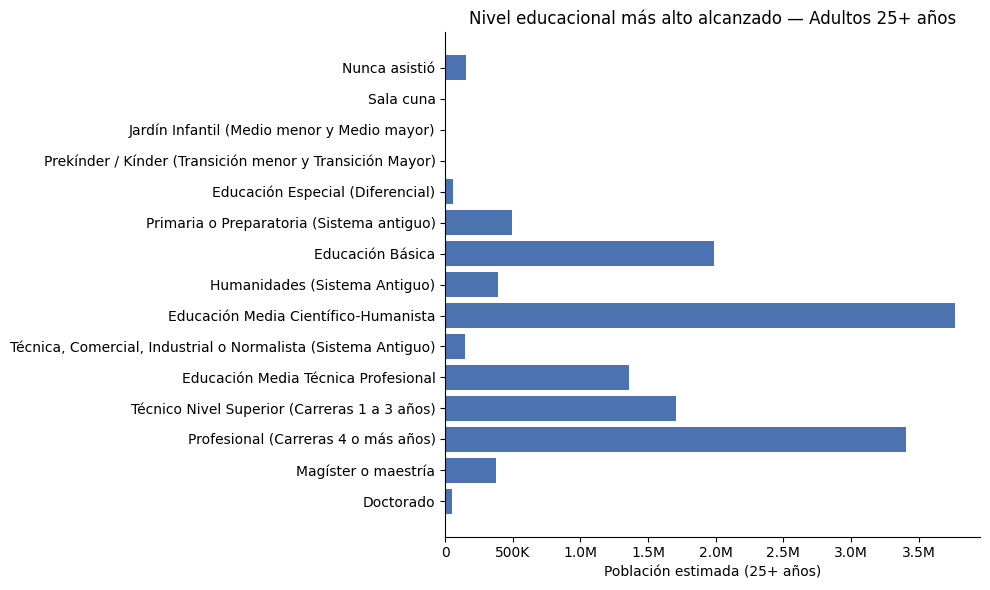


Distribución porcentual:
                                                  descripcion       pct
                                                Nunca asistió  1.118575
                                                    Sala cuna  0.002180
                  Jardín Infantil (Medio menor y Medio mayor)  0.004605
     Prekínder / Kínder (Transición menor y Transición Mayor)  0.003626
                             Educación Especial (Diferencial)  0.400769
                    Primaria o Preparatoria (Sistema antiguo)  3.549152
                                             Educación Básica 14.277160
                                Humanidades (Sistema Antiguo)  2.816387
                         Educación Media Científico-Humanista 27.098331
Técnica, Comercial, Industrial o Normalista (Sistema Antiguo)  1.057083
                          Educación Media Técnica Profesional  9.780791
                 Técnico Nivel Superior (Carreras 1 a 3 años) 12.298792
                          Profesional 

In [9]:
df_adultos = df[df["edad"] >= 25].copy()
poblacion_adultos = df_adultos["expr"].sum()

nivel_educ_dist = (
    df_adultos.groupby("codigo_nivel")["expr"].sum()
    .reset_index()
    .merge(df_nivel_educ, left_on="codigo_nivel", right_on="codigo")
    .sort_values("codigo_nivel")
)
nivel_educ_dist["pct"] = nivel_educ_dist["expr"] / poblacion_adultos * 100

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(nivel_educ_dist["descripcion"], nivel_educ_dist["expr"], color="#4C72B0")
ax.set_xlabel("Población estimada (25+ años)")
ax.set_title("Nivel educacional más alto alcanzado — Adultos 25+ años")
ax.xaxis.set_major_formatter(FORMATEADOR_MILES)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("\nDistribución porcentual:")
print(nivel_educ_dist[["descripcion", "pct"]].to_string(index=False))

### Campos de estudio en educación superior

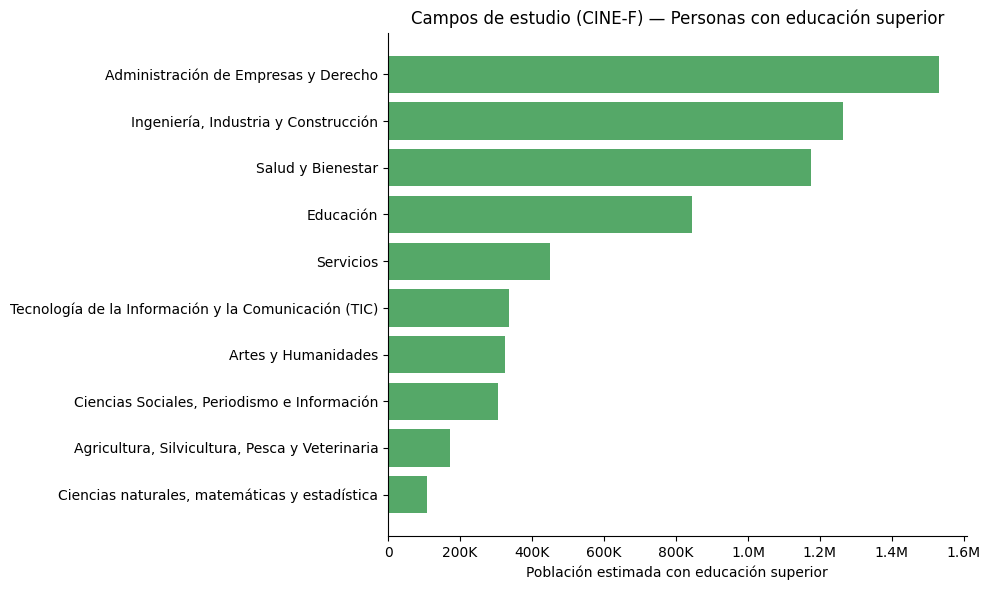


Total con educación superior estimado: 6,512,263


In [10]:
df_sup = df[df["codigo_subcampo"].notna()].copy()
poblacion_sup = df_sup["expr"].sum()

# El campo amplio se deduce del subcampo vía la tabla Subcampo_estudio
df_sup = df_sup.merge(
    df_subcampo[["codigo", "codigo_campo"]],
    left_on="codigo_subcampo", right_on="codigo",
    how="left",
)

campo_dist = (
    df_sup.groupby("codigo_campo")["expr"].sum()
    .reset_index()
    .merge(df_campo, left_on="codigo_campo", right_on="codigo")
    .sort_values("expr", ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(campo_dist["descripcion"], campo_dist["expr"], color="#55A868")
ax.set_xlabel("Población estimada con educación superior")
ax.set_title("Campos de estudio (CINE-F) — Personas con educación superior")
ax.xaxis.set_major_formatter(FORMATEADOR_MILES)
plt.tight_layout()
plt.show()

print(f"\nTotal con educación superior estimado: {poblacion_sup:,.0f}")

## Mercado laboral I — Participación

### Condición de actividad (personas 15+)

Población 15+ estimada: 16,445,525
  Ocupados:          9,467,541  (57.6%)
  Desocupados:         909,208  (5.5%)
  Inactivos:         6,068,776  (36.9%)

Tasa de participación: 63.1%
Tasa de desocupación:  8.8%


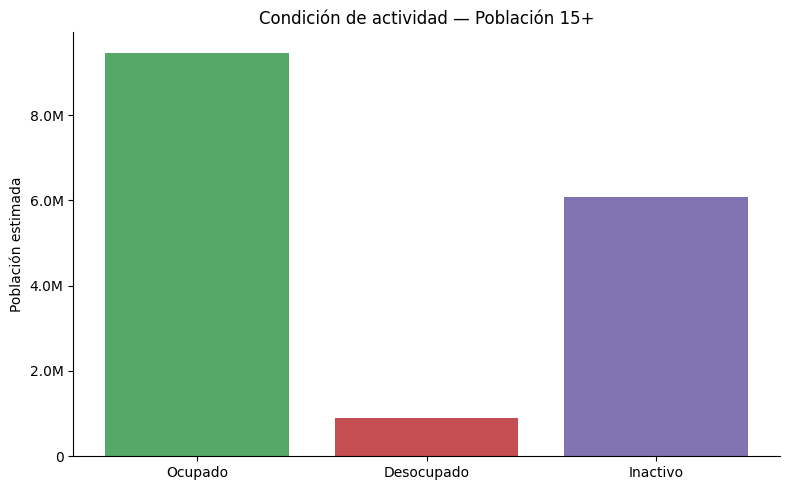

In [11]:
df_15mas = df[df["edad"] >= 15].copy()
poblacion_15mas = df_15mas["expr"].sum()

# Convención CASEN: 1 = Ocupado, 2 = Desocupado, 3 = Inactivo
etiquetas_activ = {1: "Ocupado", 2: "Desocupado", 3: "Inactivo"}

activ_dist = df_15mas.groupby("activ")["expr"].sum()
activ_dist.index = activ_dist.index.map(etiquetas_activ)

# Tasas estándar del INE
ocupados = activ_dist.get("Ocupado", 0)
desocupados = activ_dist.get("Desocupado", 0)
inactivos = activ_dist.get("Inactivo", 0)
fuerza_trabajo = ocupados + desocupados

print(f"Población 15+ estimada: {poblacion_15mas:,.0f}")
print(f"  Ocupados:    {ocupados:>15,.0f}  ({ocupados/poblacion_15mas*100:.1f}%)")
print(f"  Desocupados: {desocupados:>15,.0f}  ({desocupados/poblacion_15mas*100:.1f}%)")
print(f"  Inactivos:   {inactivos:>15,.0f}  ({inactivos/poblacion_15mas*100:.1f}%)")
print(f"\nTasa de participación: {fuerza_trabajo/poblacion_15mas*100:.1f}%")
print(f"Tasa de desocupación:  {desocupados/fuerza_trabajo*100:.1f}%")

fig, ax = plt.subplots(figsize=(8, 5))
colores = ["#55A868", "#C44E52", "#8172B2"]
ax.bar(activ_dist.index, activ_dist.values, color=colores)
ax.set_ylabel("Población estimada")
ax.set_title("Condición de actividad — Población 15+")
ax.yaxis.set_major_formatter(FORMATEADOR_MILES)
plt.tight_layout()
plt.show()

### Categoría ocupacional de los ocupados

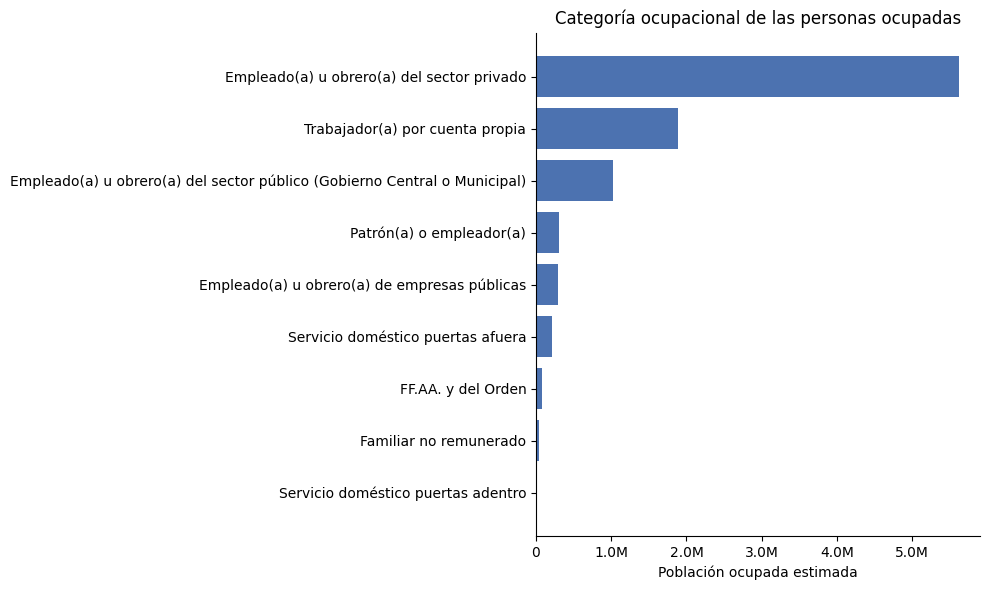

In [12]:
df_ocupados = df[df["activ"] == 1].copy()

cat_ocup_dist = (
    df_ocupados.groupby("codigo_cat_ocup")["expr"].sum()
    .reset_index()
    .merge(df_cat_ocup, left_on="codigo_cat_ocup", right_on="codigo")
    .sort_values("expr", ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(cat_ocup_dist["descripcion"], cat_ocup_dist["expr"], color="#4C72B0")
ax.set_xlabel("Población ocupada estimada")
ax.set_title("Categoría ocupacional de las personas ocupadas")
ax.xaxis.set_major_formatter(FORMATEADOR_MILES)
plt.tight_layout()
plt.show()

## Mercado laboral II — Sectores económicos

### Distribución por rama económica

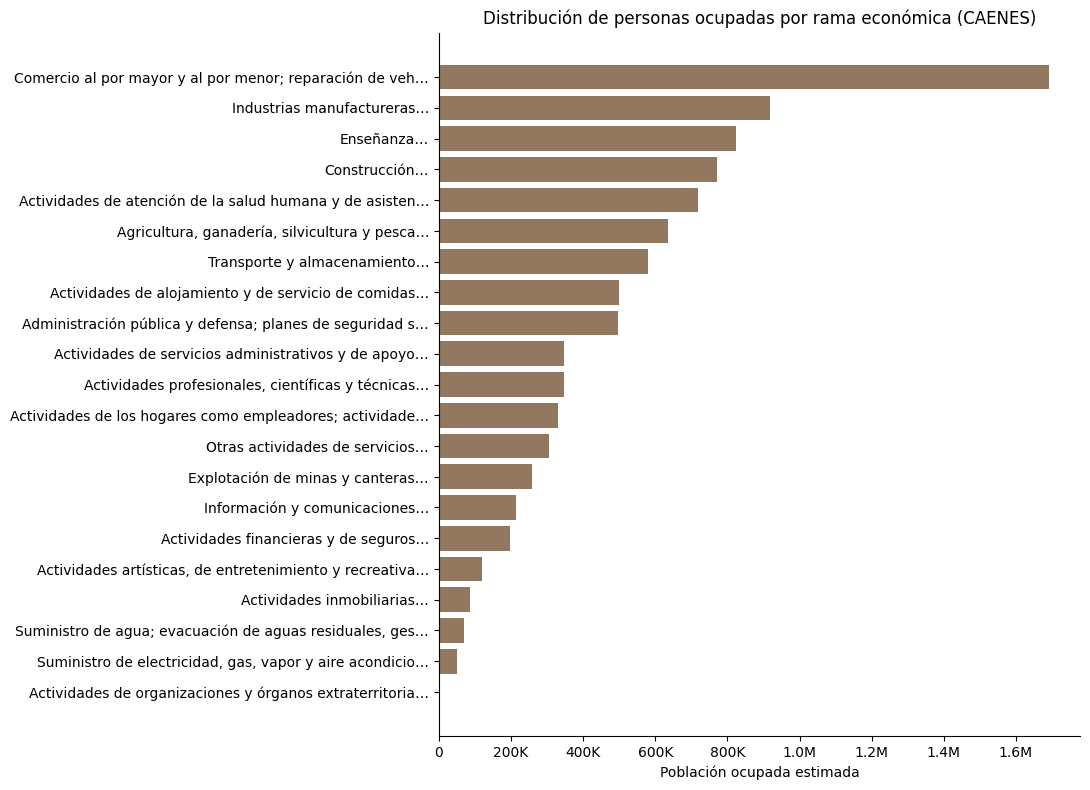

In [13]:
# La rama (rama1) se obtiene desde la subrama (rama4) vía Subrama_economica
df_ocupados_rama = df_ocupados.merge(
    df_subrama[["codigo", "codigo_rama"]],
    left_on="codigo_subrama", right_on="codigo",
    how="left",
)

rama_dist = (
    df_ocupados_rama.groupby("codigo_rama")["expr"].sum()
    .reset_index()
    .merge(df_rama, left_on="codigo_rama", right_on="codigo")
    .sort_values("expr", ascending=True)
)
rama_dist["descripcion_corta"] = rama_dist["descripcion"].str.slice(0, 55) + "…"

fig, ax = plt.subplots(figsize=(11, 8))
ax.barh(rama_dist["descripcion_corta"], rama_dist["expr"], color="#937860")
ax.set_xlabel("Población ocupada estimada")
ax.set_title("Distribución de personas ocupadas por rama económica (CAENES)")
ax.xaxis.set_major_formatter(FORMATEADOR_MILES)
plt.tight_layout()
plt.show()

## Mercado laboral III — Ingresos

### Distribución general del ingreso ocupación principal

Ingreso ocupación principal (yoprcor):
  P10:     $       250,000
  Mediana: $       600,000
  P90:     $     1,700,000
  Media:   $       857,333
  Razón P90/P10: 6.8x


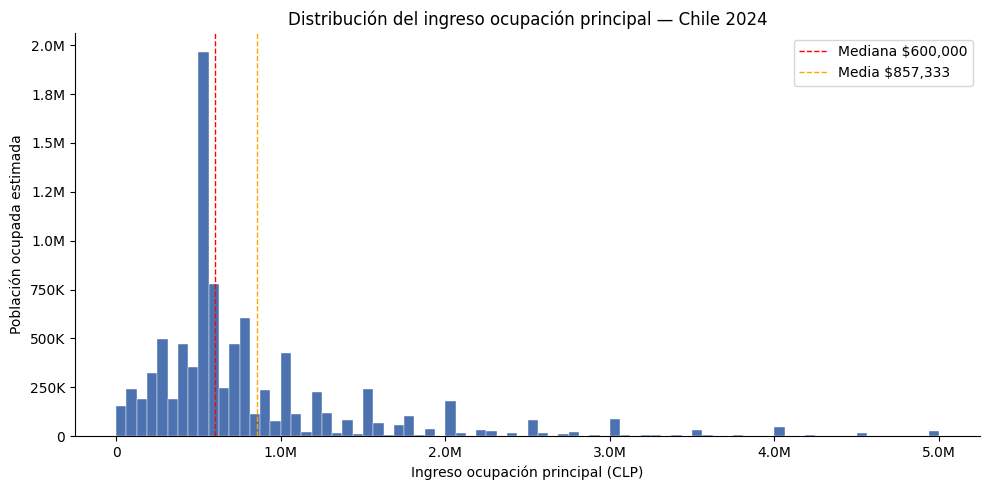

In [14]:
ingresos = df.loc[df["yoprcor"].notna(), ["yoprcor", "expr"]].copy()

# Estadísticos ponderados
p10  = percentil_ponderado(ingresos["yoprcor"], ingresos["expr"], 10)
p50  = percentil_ponderado(ingresos["yoprcor"], ingresos["expr"], 50)
p90  = percentil_ponderado(ingresos["yoprcor"], ingresos["expr"], 90)
media = np.average(ingresos["yoprcor"], weights=ingresos["expr"])

print(f"Ingreso ocupación principal (yoprcor):")
print(f"  P10:     ${p10:>14,.0f}")
print(f"  Mediana: ${p50:>14,.0f}")
print(f"  P90:     ${p90:>14,.0f}")
print(f"  Media:   ${media:>14,.0f}")
print(f"  Razón P90/P10: {p90/p10:.1f}x")

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(ingresos["yoprcor"], bins=80, weights=ingresos["expr"],
        range=(0, 5_000_000), color="#4C72B0", edgecolor="white", linewidth=0.3)
ax.axvline(p50, color="red", linestyle="--", linewidth=1, label=f"Mediana ${p50:,.0f}")
ax.axvline(media, color="orange", linestyle="--", linewidth=1, label=f"Media ${media:,.0f}")
ax.set_xlabel("Ingreso ocupación principal (CLP)")
ax.set_ylabel("Población ocupada estimada")
ax.set_title("Distribución del ingreso ocupación principal — Chile 2024")
ax.xaxis.set_major_formatter(FORMATEADOR_MILES)
ax.yaxis.set_major_formatter(FORMATEADOR_MILES)
ax.legend()
plt.tight_layout()
plt.show()

### Brecha salarial por sexo

Mediana y media de ingreso por sexo:
  Hombres: mediana $     600,000   media $     937,943
  Mujeres: mediana $     510,000   media $     748,730

Brecha en mediana: mujeres ganan 85.0% del ingreso de los hombres


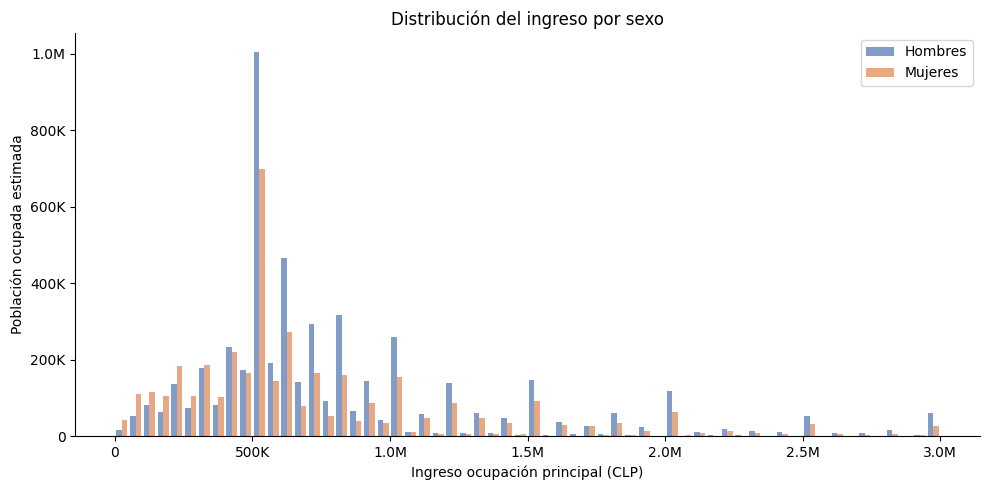

In [15]:
ingresos_sexo = df.loc[df["yoprcor"].notna(), ["yoprcor", "expr", "sexo"]].copy()

print("Mediana y media de ingreso por sexo:")
medianas_por_sexo = {}
for s, etiqueta in [(1, "Hombres"), (2, "Mujeres")]:
    sub = ingresos_sexo[ingresos_sexo["sexo"] == s]
    mediana = percentil_ponderado(sub["yoprcor"], sub["expr"], 50)
    media_s = np.average(sub["yoprcor"], weights=sub["expr"])
    medianas_por_sexo[s] = mediana
    print(f"  {etiqueta}: mediana ${mediana:>12,.0f}   media ${media_s:>12,.0f}")

brecha = medianas_por_sexo[2] / medianas_por_sexo[1] * 100
print(f"\nBrecha en mediana: mujeres ganan {brecha:.1f}% del ingreso de los hombres")

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist([ingresos_sexo[ingresos_sexo["sexo"]==1]["yoprcor"],
         ingresos_sexo[ingresos_sexo["sexo"]==2]["yoprcor"]],
        bins=60, range=(0, 3_000_000),
        weights=[ingresos_sexo[ingresos_sexo["sexo"]==1]["expr"],
                 ingresos_sexo[ingresos_sexo["sexo"]==2]["expr"]],
        label=["Hombres", "Mujeres"],
        color=["#4C72B0", "#DD8452"], alpha=0.7)
ax.set_xlabel("Ingreso ocupación principal (CLP)")
ax.set_ylabel("Población ocupada estimada")
ax.set_title("Distribución del ingreso por sexo")
ax.xaxis.set_major_formatter(FORMATEADOR_MILES)
ax.yaxis.set_major_formatter(FORMATEADOR_MILES)
ax.legend()
plt.tight_layout()
plt.show()

### Mediana de ingreso por rama económica

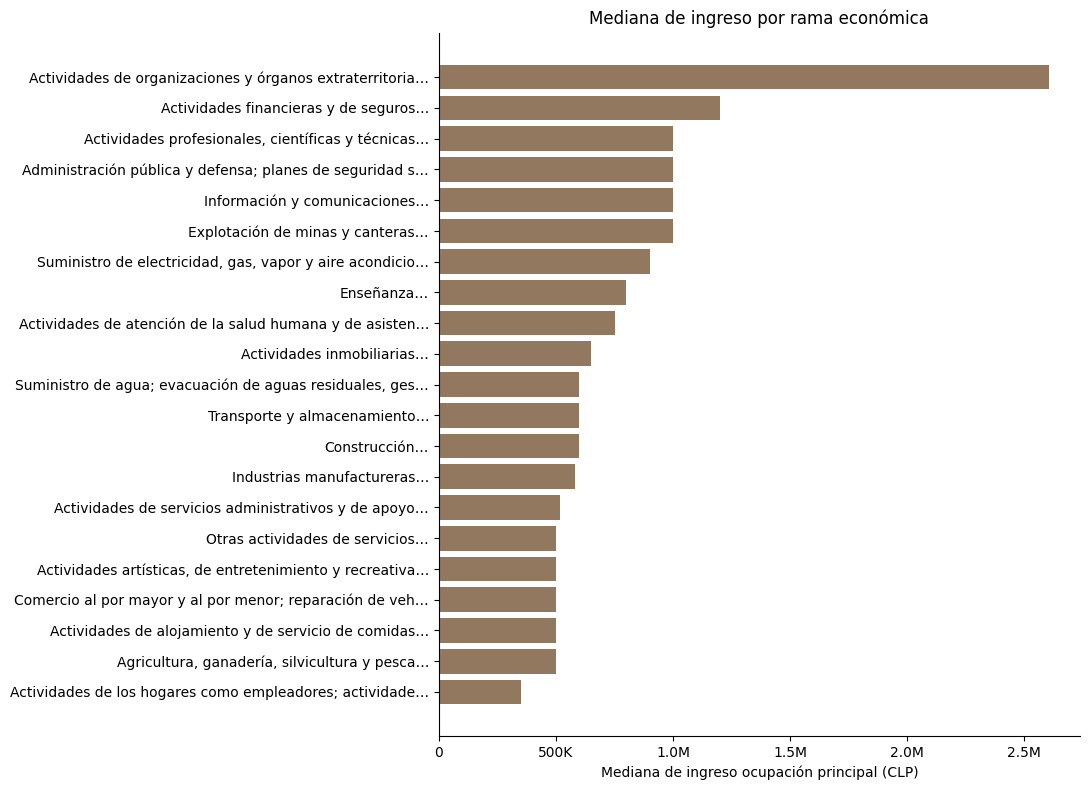

In [16]:
ingresos_rama = df_ocupados_rama.loc[
    df_ocupados_rama["yoprcor"].notna() & df_ocupados_rama["codigo_rama"].notna(),
    ["yoprcor", "expr", "codigo_rama"],
].copy()

medianas_rama = (
    ingresos_rama.groupby("codigo_rama")
    .apply(lambda g: percentil_ponderado(g["yoprcor"], g["expr"], 50), include_groups=False)
    .reset_index(name="mediana")
    .merge(df_rama, left_on="codigo_rama", right_on="codigo")
    .sort_values("mediana", ascending=True)
)
medianas_rama["descripcion_corta"] = medianas_rama["descripcion"].str.slice(0, 55) + "…"

fig, ax = plt.subplots(figsize=(11, 8))
ax.barh(medianas_rama["descripcion_corta"], medianas_rama["mediana"], color="#937860")
ax.set_xlabel("Mediana de ingreso ocupación principal (CLP)")
ax.set_title("Mediana de ingreso por rama económica")
ax.xaxis.set_major_formatter(FORMATEADOR_MILES)
plt.tight_layout()
plt.show()

### Tasa de desocupación y mediana de ingreso por región

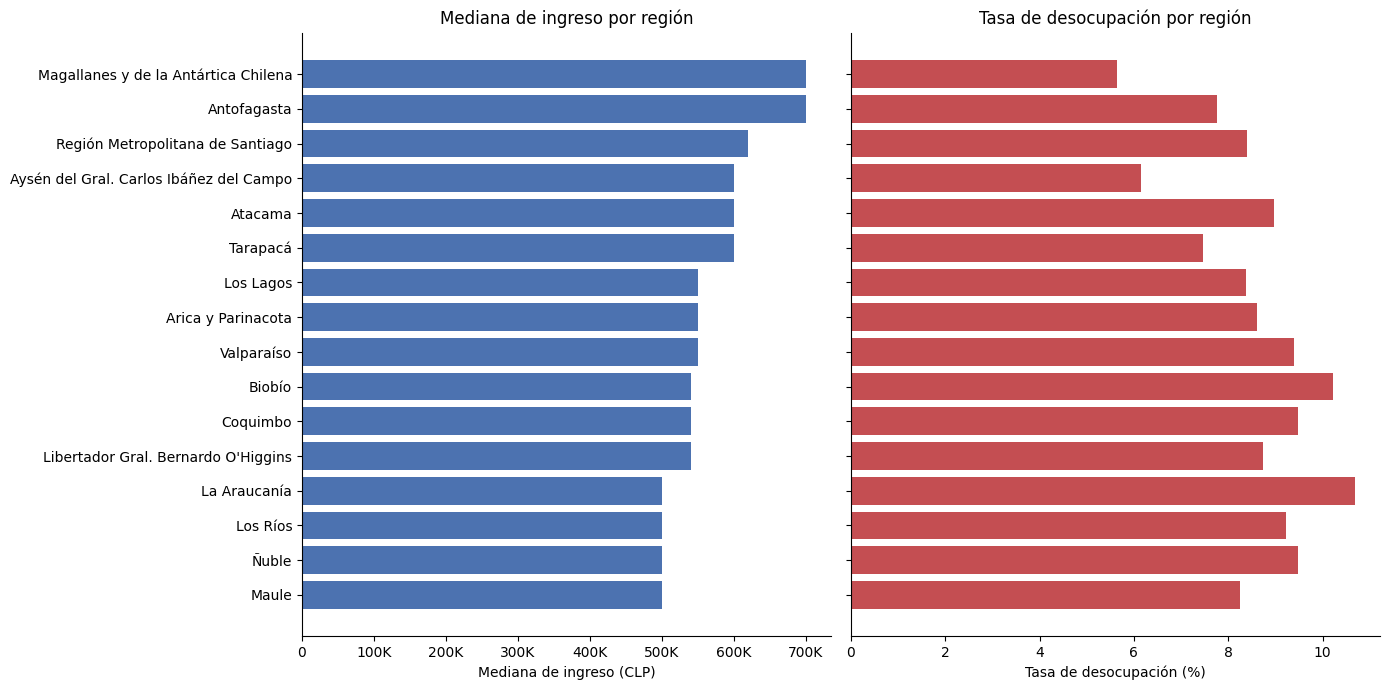

In [17]:
df_15mas_reg = df[df["edad"] >= 15].copy()

stats_region = []
for cod_reg, sub in df_15mas_reg.groupby("cod_region"):
    pob_15mas = sub["expr"].sum()
    ocup = sub.loc[sub["activ"] == 1, "expr"].sum()
    desoc = sub.loc[sub["activ"] == 2, "expr"].sum()
    fuerza = ocup + desoc
    tasa_desoc = desoc / fuerza * 100 if fuerza > 0 else np.nan

    ingresos_reg = sub.loc[sub["yoprcor"].notna(), ["yoprcor", "expr"]]
    mediana_ing = (percentil_ponderado(ingresos_reg["yoprcor"], ingresos_reg["expr"], 50)
                    if len(ingresos_reg) > 0 else np.nan)

    stats_region.append({
        "cod_region": cod_reg,
        "tasa_desocupacion": tasa_desoc,
        "mediana_ingreso": mediana_ing,
    })

df_stats_reg = (
    pd.DataFrame(stats_region)
    .merge(df_region, on="cod_region")
    .sort_values("mediana_ingreso", ascending=True)
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7), sharey=True)

ax1.barh(df_stats_reg["nombre"], df_stats_reg["mediana_ingreso"], color="#4C72B0")
ax1.set_xlabel("Mediana de ingreso (CLP)")
ax1.set_title("Mediana de ingreso por región")
ax1.xaxis.set_major_formatter(FORMATEADOR_MILES)

ax2.barh(df_stats_reg["nombre"], df_stats_reg["tasa_desocupacion"], color="#C44E52")
ax2.set_xlabel("Tasa de desocupación (%)")
ax2.set_title("Tasa de desocupación por región")

plt.tight_layout()
plt.show()

## Cruces importantes

### Retorno educacional: mediana de ingreso por nivel educativo

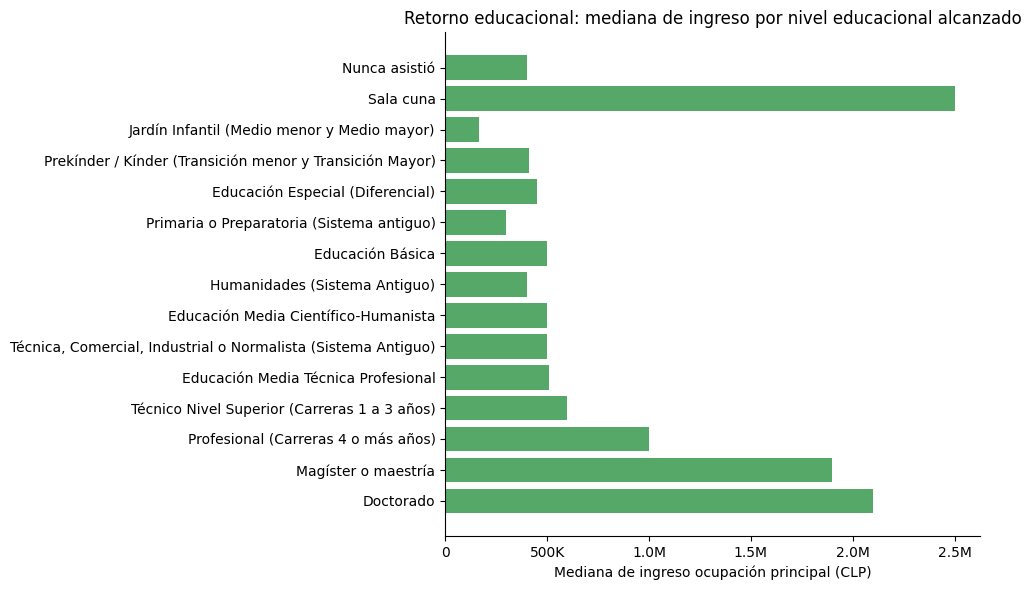

In [18]:
ingresos_educ = df.loc[df["yoprcor"].notna(), ["yoprcor", "expr", "codigo_nivel"]].copy()

medianas_educ = (
    ingresos_educ.groupby("codigo_nivel")
    .apply(lambda g: percentil_ponderado(g["yoprcor"], g["expr"], 50), include_groups=False)
    .reset_index(name="mediana")
    .merge(df_nivel_educ, left_on="codigo_nivel", right_on="codigo")
    .sort_values("codigo_nivel")
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(medianas_educ["descripcion"], medianas_educ["mediana"], color="#55A868")
ax.set_xlabel("Mediana de ingreso ocupación principal (CLP)")
ax.set_title("Retorno educacional: mediana de ingreso por nivel educacional alcanzado")
ax.xaxis.set_major_formatter(FORMATEADOR_MILES)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### Resumen

In [19]:
print("="*60)
print("RESUMEN — Mercado laboral en Chile (CASEN 2024)")
print("="*60)
print(f"Población total estimada:           {poblacion_total:>15,.0f}")
print(f"Población 15+ años:                 {poblacion_15mas:>15,.0f}")
print(f"  - Ocupados:                       {ocupados:>15,.0f}  ({ocupados/poblacion_15mas*100:.1f}%)")
print(f"  - Desocupados:                    {desocupados:>15,.0f}  ({desocupados/poblacion_15mas*100:.1f}%)")
print(f"  - Inactivos:                      {inactivos:>15,.0f}  ({inactivos/poblacion_15mas*100:.1f}%)")
print(f"Tasa de participación:              {fuerza_trabajo/poblacion_15mas*100:>14.1f}%")
print(f"Tasa de desocupación:               {desocupados/fuerza_trabajo*100:>14.1f}%")
print(f"\nIngreso ocupación principal:")
print(f"  - Mediana general:                ${p50:>14,.0f}")
print(f"  - Media general:                  ${media:>14,.0f}")
print(f"  - Razón P90/P10 (desigualdad):    {p90/p10:>14.1f}x")
print(f"  - Brecha de género (mediana M/H): {brecha:>14.1f}%")
print("="*60)

RESUMEN — Mercado laboral en Chile (CASEN 2024)
Población total estimada:                20,131,682
Población 15+ años:                      16,445,525
  - Ocupados:                             9,467,541  (57.6%)
  - Desocupados:                            909,208  (5.5%)
  - Inactivos:                            6,068,776  (36.9%)
Tasa de participación:                        63.1%
Tasa de desocupación:                          8.8%

Ingreso ocupación principal:
  - Mediana general:                $       600,000
  - Media general:                  $       857,333
  - Razón P90/P10 (desigualdad):               6.8x
  - Brecha de género (mediana M/H):           85.0%
